# Abstract
This paper details the design, implementation, and evaluation of a mean-reversion trading algorithm grounded in stochastic calculus. The primary objective is to bridge theoretical stochastic processes with applied quantitative finance by developing a consistently profitable strategy with strict risk management protocols. This study covers the mathematical foundations of the model, system architecture, and backtesting results. Additionally, it analyzes practical implementation challenges and the engineering solutions developed to address them.

## 1. Introduction

### 1.1 Context
While traditional fundamental analysis focuses on long-term value, short-term equity market dynamics can be effectively modeled using stochastic differential equations (SDEs). This paper focuses on the Ornstein-Uhlenbeck (OU) process, which models how price shocks in the stock market revert to a historical mean. Modeling this specific SDE enables statistical inference regarding the speed and magnitude of mean reversion, as well as how inherent market noise impacts price action. The foundational research for this project involved modeling market microstructure using advanced probabilistic frameworks. This included developing Hidden Markov Models (HMMs), implementing Markov Chain Monte Carlo (MCMC) methods, and applying the Central Limit Theorem (CLT) for the statistical analysis of asset distributions.

### 1.2 Strategy Selection and Hypothesis
Building upon this mathematical foundation, this paper presents an algorithmic approach to mean reversion. Mean reversion is one of the most heavily documented phenomena in financial literature, resulting in a highly efficient and crowded space in modern equity markets. However, because the underlying pricing mechanisms are well-understood, it serves as an ideal framework for testing and validating applied stochastic models.

### 1.3 Project Objectives
Despite the competitive nature of mean-reversion strategies, the primary objective of this project is not solely to discover a novel approach to modeling mean reversion. Rather, it is to engineer a consistently profitable algorithm that prioritizes rigorous, mathematically driven risk management. By treating the market as a continuous stochastic process, this model attempts to execute statistical arbitrage while systematically constraining downside exposure.


## 3. Methodology

### 3.1 The Ornstein-Uhlenbeck (OU) Process

To model mean-reverting behavior in equity prices, this algorithm utilizes the Ornstein-Uhlenbeck (OU) process. The dynamics of the asset price are governed by the following stochastic differential equation (SDE):

$$dx_t = \theta(\mu - x_t)dt + \sigma dW_t$$

This equation breaks the price movement down into two distinct components: a deterministic drift term that pulls the price toward an equilibrium, and a stochastic diffusion term that introduces market randomness.

The parameters of the model are defined as follows:

* **$x_t$**: The current price of the asset at time $t$.
* **$\mu$**: The stationary (or long-term) mean. This is the equilibrium price that the asset naturally gravitates toward. Assuming the market regime remains stable, as $t \to \infty$, the expected value of the price converges to $\mu$.
* **$\theta$**: The speed of mean reversion. This dictates how aggressively the price is pulled back toward $\mu$. 
* **$\theta(\mu - x_t)dt$**: The deterministic drift component. The term $(\mu - x_t)$ measures the exact distance and direction of the current price from the mean. Multiplying this distance by $\theta$ models the gravitational pull bringing the price back to equilibrium over the time increment $dt$.
* **$\sigma$**: The volatility of the asset. This represents the magnitude of price impact generated by the continuous flow of buy and sell orders in the market.
* **$dW_t$**: The increment of a standard Brownian motion (or Wiener process). This captures the inherent, unpredictable random noise of the stock market.
* **$\sigma dW_t$**: The stochastic diffusion component. It represents the overall strength of random market shocks pushing the price in unpredictable directions during the time step $dt$.

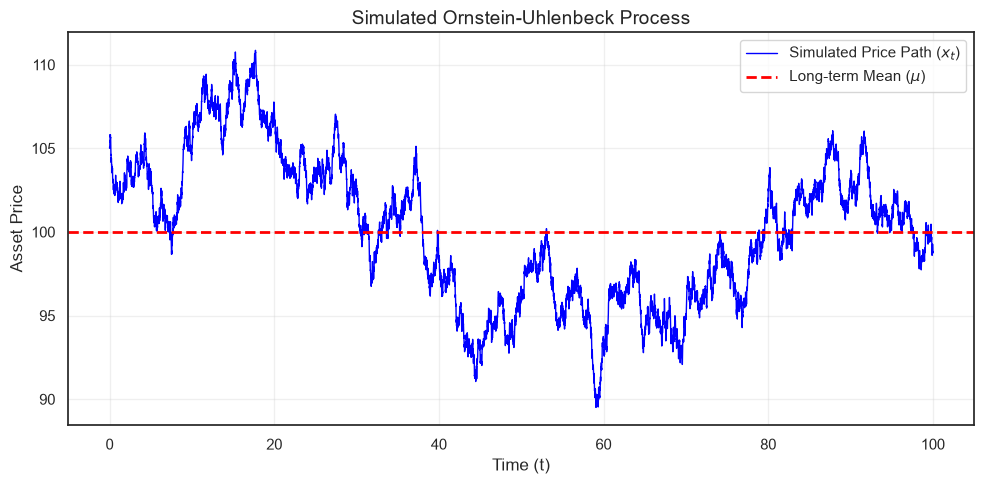

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Parameters
mu = 100.0      # Long-term mean
theta = 0.15    # Speed of mean reversion
sigma = 2.0     # Volatility
dt = 0.01       # Time step
T = 100         # Total time
N = int(T / dt) # Number of steps

# 2. Initialize Arrays
t = np.linspace(0, T, N)
x = np.zeros(N)
x[0] = 105.0    # Starting price (slightly above the mean)

# 3. Euler-Maruyama Simulation of the SDE
np.random.seed(42) # For reproducibility in your paper
for i in range(1, N):
    dW = np.random.normal(0, np.sqrt(dt))
    # dx = theta * (mu - x) * dt + sigma * dW
    x[i] = x[i-1] + theta * (mu - x[i-1]) * dt + sigma * dW

# 4. Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(t, x, label='Simulated Price Path ($x_t$)', color='blue', linewidth=1)
plt.axhline(mu, color='red', linestyle='--', linewidth=2, label='Long-term Mean ($\mu$)')

# Academic formatting
plt.title('Simulated Ornstein-Uhlenbeck Process', fontsize=14)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Asset Price', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()

### 3.2 Parameter Estimation via Markov Chain Monte Carlo (MCMC)

The primary challenge in deploying the Ornstein-Uhlenbeck (OU) process is accurately estimating the parameters $\mu$, $\theta$, and $\sigma$. If the stock market were perfectly stationary, solving for these variables would be a trivial exercise. However, because equity markets continuously shift between different regimes and the intervals between volatility shocks are constantly changing, static parameter estimations inevitably break down. 

While practitioners typically rely on standard Maximum Likelihood Estimation (MLE) to find point estimates, this approach fails to capture statistical uncertainty. To evaluate this uncertainty and adapt dynamically as prices mature, this model applies a Markov Chain Monte Carlo (MCMC) algorithm to generate data-driven posterior probability distributions for the parameter set $\Theta = [\theta, \mu, \sigma]$.

**Data Windowing and Initialization**
MCMC generates probability distributions of multi-dimensional data to best explain underlying patterns by exploring high-density probability areas. The model is calibrated over a rolling window of 130 hourly ticks, representing approximately 21 days of active market data. I arrived at this specific window size through empirical and algorithmic tuning—evaluating various dataset sizes and scoring them based on the quality of the resulting normal distributions. This testing revealed that 130 ticks provided the optimal balance, maximizing data depth without lagging behind sudden regime shifts.

To prepare the data, the 21-day set is vectorized into an array of current prices ($X_t$) and a shifted array representing the subsequent prices ($X_{t+1}$). The algorithm initializes by utilizing a baseline MLE-style estimation (derived from an AR(1) linear regression) as the prior guess to seed the starting state. 

**The Proposal Step**
From this initial guess, the algorithm iteratively generates proposed states by adding or subtracting random micro-steps drawn from finely tuned interval spaces:

$$ \Theta_{proposed} = \Theta_{current} + \epsilon $$

*(Where $\epsilon$ represents the tuned step-size bounds for each parameter to maintain an optimal acceptance rate).*

**The Exact OU Log-Likelihood Function**
Once defined, these proposed states are evaluated using an exact OU log-likelihood function. This function checks mathematically how well the proposed parameters describe the actual observed data transitioning from $X_t$ to $X_{t+1}$. Because the transition density of the OU process is Gaussian, the algorithm calculates the sum of the log-likelihoods ($LL$) across the 130-tick window using the conditional expectation ($\hat{\mu}$) and conditional variance ($\hat{\sigma}^2$):

$$ LL(\Theta) = \sum_{i=1}^{N} \left( -\frac{1}{2} \ln(2\pi \hat{\sigma}^2) - \frac{(X_{t+1} - \hat{\mu})^2}{2\hat{\sigma}^2} \right) $$

Where the expected mean and variance for a given time step $\Delta t$ are defined as:
$$ \hat{\mu} = X_t e^{-\theta \Delta t} + \mu(1 - e^{-\theta \Delta t}) $$
$$ \hat{\sigma}^2 = \frac{\sigma^2}{2\theta}(1 - e^{-2\theta \Delta t}) $$

**The Metropolis-Hastings Acceptance Criterion**
Finally, the algorithm processes these results through a Metropolis-Hastings acceptance step to determine whether to keep the proposed state. The probability of accepting the proposed parameter state ($\alpha$) is calculated in log-space:

$$ \alpha = \min \left(1, \exp(LL_{proposed} - LL_{current}) \right) $$

If the proposed state better explains the market data ($LL_{proposed} > LL_{current}$), it is accepted deterministically. If it yields a lower likelihood, it is accepted probabilistically based on the ratio $\alpha$. This stochastic acceptance prevents the chain from becoming trapped in local optima, allowing it to fully map the likely distributions of $\mu$, $\theta$, and $\sigma$. After discarding a 10% burn-in period to remove initialization bias, the remaining samples form the true posterior distribution used to drive the trading logic.

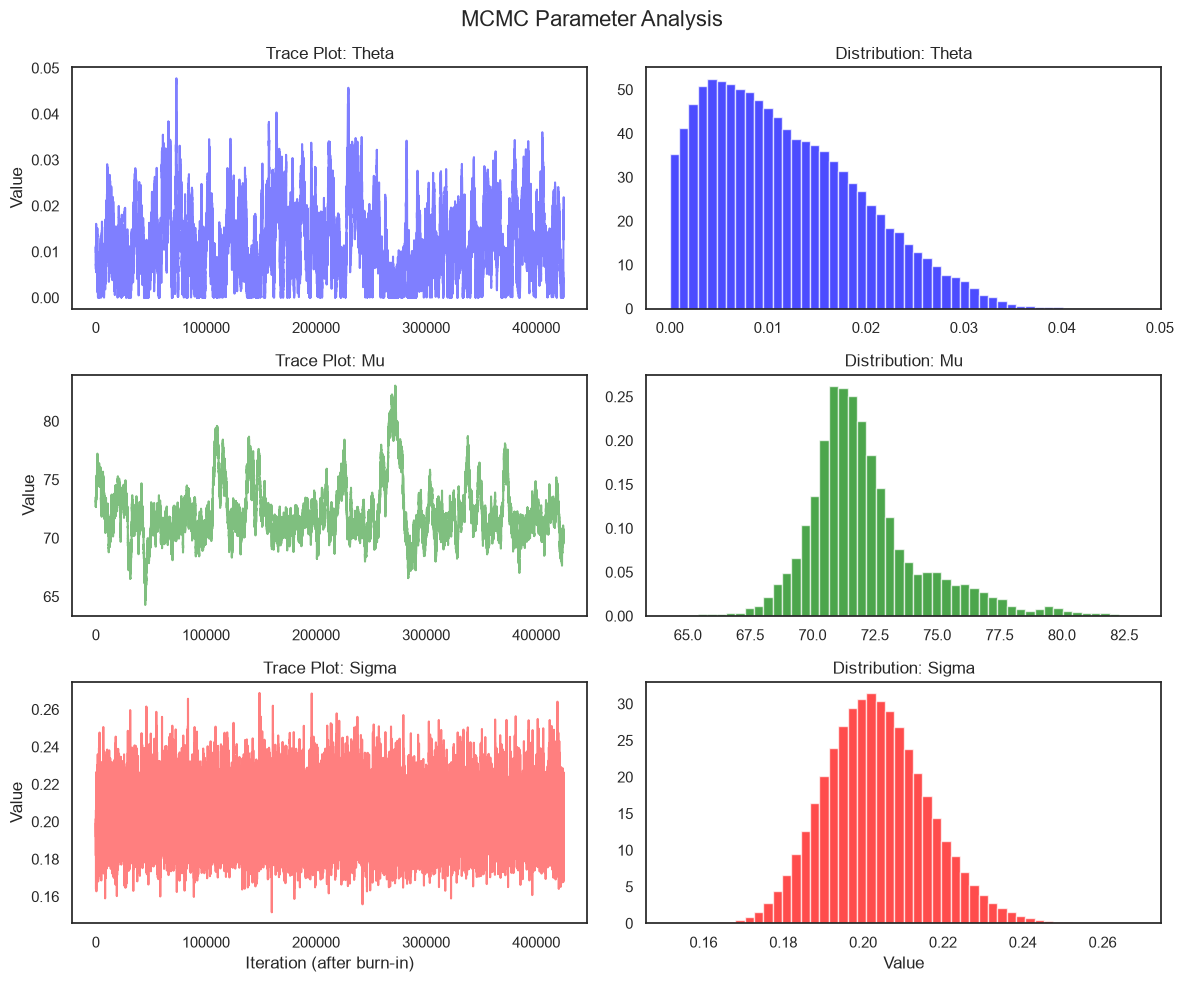

In [41]:
# @title
import numpy as np
import pandas as pd
import yfinance as yf
import importlib

# 1. Custom Imports (Make sure these match your local file names)
# (Assuming your custom MCMC and streamer functions are imported here)
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import numpy as np
import pandas as pd
import random
import numpy as np
from scipy.stats import gaussian_kde
import numpy as np
from scipy.stats import skew, kurtosis
import numpy as np
import pandas as pd
import yfinance as yf


# ==========================================
# 0. Top-Level Helper Functions
# ==========================================
def calculate_rolling_window(window, price_col="KO_Open"):
    """Separates the rolling window into historical prices and the live tick."""
    # Use price_col if available, otherwise default to the first column
    col = price_col if price_col in window.columns else window.columns[0]

    history = window.iloc[:-1]
    live_tick = window.iloc[-1]

    historical_price = history[col]
    current_tick = float(live_tick[col])

    return historical_price, current_tick


def calculate_adx(df, period=21):
    """Calculates ADX using Wilder's Smoothing."""
    high, low, close = df["High"], df["Low"], df["Close"]

    tr1 = high - low
    tr2 = np.abs(high - close.shift(1))
    tr3 = np.abs(low - close.shift(1))
    tr = pd.DataFrame({"tr1": tr1, "tr2": tr2, "tr3": tr3}).max(axis=1)

    up_move = high.diff()
    down_move = low.shift(1) - low
    plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

    tr_smooth = tr.ewm(alpha=1 / period, adjust=False).mean()
    plus_dm_smooth = (
        pd.Series(plus_dm, index=df.index)
        .ewm(alpha=1 / period, adjust=False)
        .mean()
    )
    minus_dm_smooth = (
        pd.Series(minus_dm, index=df.index)
        .ewm(alpha=1 / period, adjust=False)
        .mean()
    )

    plus_di = 100 * (plus_dm_smooth / tr_smooth)
    minus_di = 100 * (minus_dm_smooth / tr_smooth)

    dx = 100 * np.abs(plus_di - minus_di) / (plus_di + minus_di)
    return dx.ewm(alpha=1 / period, adjust=False).mean()


def calculate_hurst(series, max_lag=45):
    """Calculates the Hurst Exponent using Rescaled Range (R/S) Analysis."""
    ts = np.asarray(series)
    if len(ts) < max_lag:
        return 0.5

    lags = range(10, max_lag)
    rs_results = []

    for lag in lags:
        num_chunks = len(ts) // lag
        if num_chunks < 1:
            continue

        rs_chunks = []
        for i in range(num_chunks):
            chunk = ts[i * lag : (i + 1) * lag]
            mean = np.mean(chunk)
            cum_dev = np.cumsum(chunk - mean)

            R = np.max(cum_dev) - np.min(cum_dev)
            S = np.std(chunk)

            if S > 0:
                rs_chunks.append(R / S)

        if len(rs_chunks) > 0:
            rs_results.append((lag, np.mean(rs_chunks)))

    if len(rs_results) < 2:
        return 0.5

    log_lags = np.log([item[0] for item in rs_results])
    log_rs = np.log([item[1] for item in rs_results])

    return float(np.polyfit(log_lags, log_rs, 1)[0])


# ==========================================
# 1. Standard Real-Time Streamer (3-tuple)
# ==========================================
def real_time_streamer(df, lookback_periods=210):
    """Streams datetimes, historical lookback prices, and the live tick price."""
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    if len(df) <= lookback_periods:
        raise ValueError(
            f"Dataset only has {len(df)} rows, but needs {lookback_periods} for"
            " lookback."
        )

    for i in range(lookback_periods, len(df)):
        window = df.iloc[i - lookback_periods : i + 1]
        current_time_label = df.index[i]

        historical_price, current_tick = calculate_rolling_window(window)

        yield current_time_label, historical_price, current_tick


# ==========================================
# 2. HMM Real-Time Streamer 2 (4-tuple)
# ==========================================
def real_time_streamer2(df_KO, lookback_periods=210):
    """Calculates all technical indicators on df_KO first, then streams:

    - current_time_label
    - historical_price
    - current_tick
    - live_features_df (1-row DataFrame containing HMM features)
    """
    df = df_KO.copy()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    if len(df) <= lookback_periods:
        raise ValueError(
            f"Dataset only has {len(df)} rows, but needs {lookback_periods} for"
            " lookback."
        )

    target_price = "KO_Open" if "KO_Open" in df.columns else df.columns[0]

    # --- Pre-compute HMM Features ---
    print("Calculating HMM features for real-time streaming...")
    df["log_return"] = np.log(df[target_price] / df[target_price].shift(1))
    df["real_volatility"] = df["log_return"].rolling(window=25).std()

    fast_ma = df[target_price].rolling(window=20).mean()
    slow_ma = df[target_price].rolling(window=130).mean()
    df["ma_spread"] = (fast_ma - slow_ma) / slow_ma

    df["roc_20"] = df[target_price].pct_change(periods=20)
    df["smooth_momentum"] = df["roc_20"].ewm(span=20, adjust=False).mean()

    df["adx"] = calculate_adx(df, period=21)

    df["hurst_exponent"] = (
        df[target_price]
        .rolling(window=130)
        .apply(lambda x: calculate_hurst(x, max_lag=45), raw=True)
    )

    # --- Handle Extreme Outliers ---
    df["log_return"] = df["log_return"].clip(
        lower=df["log_return"].quantile(0.01),
        upper=df["log_return"].quantile(0.99),
    )
    df["smooth_momentum"] = df["smooth_momentum"].clip(
        lower=df["smooth_momentum"].quantile(0.01),
        upper=df["smooth_momentum"].quantile(0.99),
    )

    # Features expected by the trained HMM
    #feature_columns = ["smooth_momentum", "log_return", "adx", "ma_spread"]
    feature_columns = ["smooth_momentum", "log_return", "adx", "ma_spread"]

    # --- Live Stream Yield Loop ---
    for i in range(lookback_periods, len(df)):
        window = df.iloc[i - lookback_periods : i + 1]
        current_time_label = df.index[i]

        historical_price, current_tick = calculate_rolling_window(
            window, price_col=target_price
        )

        # 1-row DataFrame containing features for current_tick
        #live_features_df = df.iloc[[i]][feature_columns]
        live_features_df = window[feature_columns]

        yield current_time_label, historical_price, current_tick, live_features_df
# thick later to add inter day stock day chaign dt and xt to be cdaeilssick insated 
def parms_distribution(xt, total_iterations=1000000,dt=1): # xtis stock data dt is the diffrece between the current day and the next day
 
    from sklearn.linear_model import LinearRegression

    def get_initial_guesses(xt_vals, dt=1):
        # Slice data into t and t+1
        x_current = xt_vals[:-1].reshape(-1, 1)
        x_next = xt_vals[1:]
        
        # Run quick linear regression: X_{t+1} = slope * X_t + intercept
        reg = LinearRegression().fit(x_current, x_next)
        slope = reg.coef_[0]
        intercept = reg.intercept_
        
        # Calculate residuals to get empirical volatility
        predictions = reg.predict(x_current)
        residuals = x_next - predictions
        residual_std = np.std(residuals)
        
        # Translate AR(1) regression coefficients into OU parameters
        # 1. Theta (speed of mean reversion)
        if slope > 0 and slope < 1:
            theta_start = -np.log(slope) / dt
        else:
            theta_start = 0.1  # Fallback if data isn't mean-reverting today
            
        # 2. Mu (long-term mean)
        if slope != 1:
            mu_start = intercept / (1 - slope)
        else:
            mu_start = np.mean(xt_vals) # Fallback to simple average
            
        # 3. Sigma (volatility)
        sigma_start = residual_std / np.sqrt(dt)
        
        # Quick safety guardrails to ensure positive values
        theta_start = max(theta_start, 0.001)
        sigma_start = max(sigma_start, 0.001)
        
        return theta_start, mu_start, sigma_start

    def ou_log_likelihood(x_current, x_next, dt, theta, mu, sigma): # Current is xt so the lcsoeing precei on the dat next isn the closing price of the next day
        # Enforce strict positive constraints
        if theta <= 0 or sigma <= 0:
            return -float('inf')
            
        expected_mean = x_current * np.exp(-theta * dt) + mu * (1 - np.exp(-theta * dt))
        expected_var = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * dt))
        
        # Catch tiny float or negative variance edge cases
        if expected_var <= 0:
            return -float('inf')
            
        term1 = -0.5 * np.log(2 * np.pi * expected_var)
        term2 = -((x_next - expected_mean) ** 2) / (2 * expected_var)

        return np.sum(term1 + term2)


    def run_mcmc(current_vector, total_iterations, x_current_series, x_next_series, time_step):# you will ocntuiers updat the cuccuten adn next saera to run the mcmc on
        samples = []
        current_state = list(current_vector)
        
        # Pre-calculate baseline score
        current_score = ou_log_likelihood(
            x_current_series, x_next_series, time_step, 
            current_state[0], current_state[1], current_state[2] # mu theta and sigma
        )
        
        for i in range(total_iterations):
            # Generate micro-scaled steps matched to each parameter's baseline size
            step_theta = random.uniform(-0.0007, 0.0007)
            step_mu    = random.uniform(-0.1, 0.1)
            step_sigma = random.uniform(-0.005, 0.005)
            
            proposed_state = [
                current_state[0] + step_theta,
                current_state[1] + step_mu,
                current_state[2] + step_sigma
            ]
            
            # Boundary constraints check to prevent code crashes before running likelihood math
            if proposed_state[0] <= 0 or proposed_state[2] <= 0:
                proposed_score = -float('inf')
            else:
                proposed_score = ou_log_likelihood(
                    x_current_series, x_next_series, time_step, 
                    proposed_state[0], proposed_state[1], proposed_state[2]
                )
                
            # Metropolis-Hastings acceptance step for log-likelihood scales
            if proposed_score == -float('inf'):
                acceptance_ratio = 0.0
            else:
                # Subtraction in log space represents division in raw probability space
                acceptance_ratio = np.exp(proposed_score - current_score)
                
            if random.random() < acceptance_ratio:
                current_state = proposed_state
                current_score = proposed_score
                
            samples.append(list(current_state))
            
        # Return everything after the 10% burn-in period to guarantee equilibrium
        burn_in_index = int(total_iterations * 0.15)
        return samples[burn_in_index:]



    
    
    # file will take in integation data form windoe in a vectore list of day to day sotkc preices
    # Normalize input to a pandas Series then to a NumPy array
    xt_series = pd.Series(xt).dropna()
    xt_vals = xt_series.values

    # Paired arrays of equal length
    x_current_series = xt_vals[:-1]
    x_next_series = xt_vals[1:]

    x_t1_data = x_next_series
    xt_data = x_current_series

    # 5. Initialize Parameters and Set Data Window
    # Starting points from your initial regression
    theta_start, mu_start, sigma_start = get_initial_guesses(xt_vals, dt=1)  # calulated from the last 30 day window or the last regeim window as an intal geuses tehn tun ethem with mcmc
    initial_vector = [theta_start, mu_start, sigma_start]

    mcmc_samples = run_mcmc(initial_vector, total_iterations, xt_data, x_t1_data, dt)
    
    
    return mcmc_samples 



def ou_zscore(current_tick, theta, mu, sigma):
    """
    Calculates the z-score for an Ornstein-Uhlenbeck process.
    """
    return (current_tick - mu) / np.sqrt((sigma**2) / (2 * theta))


import matplotlib.pyplot as plt
def analyze_and_graph_samples(mcmc_samples):
    # Convert the list of samples to a numpy array for easy slicing
    samples_array = np.array(mcmc_samples)
    
    # Check if the array is empty to prevent crashes
    if len(samples_array) == 0:
        
        return

    # Extract individual parameter chains
    theta_samples = samples_array[:, 0]
    mu_samples = samples_array[:, 1]
    sigma_samples = samples_array[:, 2]

    # --- 1. OUTPUT THE RAW DATA ---
   
    # Put it in a pandas DataFrame so it prints cleanly
    df_samples = pd.DataFrame(samples_array, columns=['Theta', 'Mu', 'Sigma'])
    
   

    # --- 2. GRAPH THE DATA ---
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    fig.suptitle('MCMC Parameter Analysis', fontsize=16)

    # Plot Trace for Theta (Shows the step-by-step path)
    axes[0, 0].plot(theta_samples, color='blue', alpha=0.5)
    axes[0, 0].set_title('Trace Plot: Theta')
    axes[0, 0].set_ylabel('Value')

    # Plot Histogram for Theta (Shows the final distribution)
    axes[0, 1].hist(theta_samples, bins=50, color='blue', alpha=0.7, density=True)
    axes[0, 1].set_title('Distribution: Theta')

    # Plot Trace for Mu
    axes[1, 0].plot(mu_samples, color='green', alpha=0.5)
    axes[1, 0].set_title('Trace Plot: Mu')
    axes[1, 0].set_ylabel('Value')

    # Plot Histogram for Mu
    axes[1, 1].hist(mu_samples, bins=50, color='green', alpha=0.7, density=True)
    axes[1, 1].set_title('Distribution: Mu')

    # Plot Trace for Sigma
    axes[2, 0].plot(sigma_samples, color='red', alpha=0.5)
    axes[2, 0].set_title('Trace Plot: Sigma')
    axes[2, 0].set_ylabel('Value')
    axes[2, 0].set_xlabel('Iteration (after burn-in)')

    # Plot Histogram for Sigma
    axes[2, 1].hist(sigma_samples, bins=50, color='red', alpha=0.7, density=True)
    axes[2, 1].set_title('Distribution: Sigma')
    axes[2, 1].set_xlabel('Value')

    plt.tight_layout()
    plt.show()


# --- Example of how you would use it ---
# metrics_output = summary_statistics(current_tick, mcmc_samples)
# plot_z_distribution(metrics_output)

# ==========================================
# 2. Download 1-Hour Data
# ==========================================
ko_ticker = yf.Ticker("KO")

# FIX: yfinance allows a maximum of 730 days for 1-hour intervals. 
# Using "730d" and "1h" ensures it won't fail and return an empty dataframe.
df_KO = ko_ticker.history(period="2y", interval="1h")

# Format for the streamer
df_KO.rename(columns={'Open': 'KO_Open'}, inplace=True)

# 1. Convert index to DatetimeIndex explicitly
df_KO.index = pd.to_datetime(df_KO.index)

# 2. Now it is safe to check for and strip the timezone
if df_KO.index.tz is not None:
    df_KO.index = df_KO.index.tz_localize(None)

# ==========================================
# 3. Initialize the Streamer with a 210-Tick Window
# ==========================================
# 7 trading hours per day * 30 days = 210 ticks (~1 month lookback window)
lookback_ticks = 130
data_feed = real_time_streamer(df_KO, lookback_periods=lookback_ticks)

# --- SINGLE TICK TEST RUN ---

# 4. Grab exactly ONE tick window from your feed
single_tick_data = next(data_feed)

# Unpack the single-asset variables
current_date, historical_price, current_tick = single_tick_data


# Extract the history vector for the MCMC
history_vector = historical_price.values


single_tick_mcmc_samples = parms_distribution(history_vector, total_iterations=500000, dt=1)


analyze_and_graph_samples(single_tick_mcmc_samples)



### 3.3 Hidden Markov Model (HMM) for Regime Classification

#### 3.3.1 Motivation and Feature Engineering
A fundamental vulnerability of mean-reverting algorithms is their susceptibility to strong directional market regimes. During aggressive bull or bear trends, asset prices cease to revert to calculated historical means and instead undergo prolonged structural shifts driven by macroeconomic or institutional order flow. Executing a mean-reversion strategy in a trending market leads to persistent adverse selection and catastrophic drawdowns.

To enforce stationarity and validate the underlying assumptions of the Ornstein-Uhlenbeck process, this model incorporates a Hidden Markov Model (HMM). The HMM acts as a real-time probabilistic regime filter, classifying market conditions into hidden states (e.g., *Mean-Reverting/Ranging* vs. *Strongly Trending*). Trading signals generated by the OU-MCMC framework are executed **only** when the HMM decodes the active regime as mean-reverting.

The observation vector at time $t$, denoted as $O_t$, is constructed from four engineered features:
$$O_t = \begin{bmatrix} \text{Log Return}_t \\ \text{Smooth Momentum}_t \\ \text{ADX}_t \\ \text{MA Spread}_t \end{bmatrix}$$

*   **Log Return ($r_t$):** $\ln(P_t / P_{t-1})$, capturing instant price velocity.
*   **Smooth Momentum:** Exponentially smoothed momentum filtering micro-structural noise.
*   **Average Directional Index (ADX):** Quantifies overall trend strength, independent of direction.
*   **Moving Average Spread (MA Spread):** Distance between a short-term moving average and long-term moving average ($MA_{short} - MA_{long}$), measuring trend divergence.

---

#### 3.3.2 Mathematical Formulation of the HMM
The market is assumed to transition among a discrete set of $K$ unobservable (hidden) states $S = \{s_1, s_2, \dots, s_K\}$. An HMM is uniquely parametrized by the triplet $\lambda = (\pi, A, B)$:

1.  **Initial State Probability Vector ($\pi$):**
    $$\pi_i = P(q_1 = s_i), \quad 1 \le i \le K$$
    where $q_t$ denotes the hidden state at time $t$.

2.  **State Transition Probability Matrix ($A$):**
    $$A = (a_{ij}), \quad a_{ij} = P(q_{t+1} = s_j \mid q_t = s_i)$$
    where $a_{ij}$ represents the probability of transitioning from state $s_i$ to state $s_j$.

3.  **Emission Probability Distribution ($B$):**
    $$B = \{b_j(O_t)\}, \quad b_j(O_t) = P(O_t \mid q_t = s_j)$$
    Because the observation vector $O_t$ consists of continuous variables, $b_j(O_t)$ is modeled as a multivariate Gaussian distribution:
    $$b_j(O_t) = \mathcal{N}(O_t \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)$$
    where $\boldsymbol{\mu}_j$ and $\boldsymbol{\Sigma}_j$ are the state-dependent mean vector and covariance matrix, respectively.

---

#### 3.3.3 Parameter Estimation: The Baum-Welch (Forward-Backward) Algorithm
To optimize the HMM parameters $\lambda = (\pi, A, B)$ based on historical feature observations $O = (O_1, O_2, \dots, O_T)$, the model uses the Baum-Welch algorithm—an Expectation-Maximization (EM) technique utilizing forward and backward probability variables.

**1. The Forward Variable ($\alpha_t(i)$):**
The probability of observing the partial sequence $(O_1, O_2, \dots, O_t)$ and being in state $s_i$ at time $t$:
$$\alpha_t(i) = P(O_1, O_2, \dots, O_t, q_t = s_i \mid \lambda)$$

*   *Initialization:* 
    $$\alpha_1(i) = \pi_i b_i(O_1), \quad 1 \le i \le K$$
*   *Induction:* 
    $$\alpha_{t+1}(j) = \left[ \sum_{i=1}^K \alpha_t(i) a_{ij} \right] b_j(O_{t+1}), \quad 1 \le t \le T-1$$

**2. The Backward Variable ($\beta_t(i)$):**
The probability of observing the remaining sequence $(O_{t+1}, O_{t+2}, \dots, O_T)$ given state $s_i$ at time $t$:
$$\beta_t(i) = P(O_{t+1}, O_{t+2}, \dots, O_T \mid q_t = s_i, \lambda)$$

*   *Initialization:* 
    $$\beta_T(i) = 1, \quad 1 \le i \le K$$
*   *Induction:* 
    $$\beta_t(i) = \sum_{j=1}^K a_{ij} b_j(O_{t+1}) \beta_{t+1}(j), \quad t = T-1, T-2, \dots, 1$$

Through iterative expectation and maximization steps using $\alpha_t(i)$ and $\beta_t(i)$, the algorithm updates $\pi$, $A$, $\boldsymbol{\mu}_j$, and $\boldsymbol{\Sigma}_j$ until likelihood convergence is reached.

---

#### 3.3.4 Regime Decoding: The Viterbi Algorithm
While the Baum-Welch algorithm trains the model's parameters, it does not reveal the underlying sequence of hidden market states. To solve the **decoding problem**—finding the single most likely sequence of hidden market regimes $Q^* = (q_1^*, q_2^*, \dots, q_T^*)$ given the observation sequence $O$—the model executes the **Viterbi Algorithm**.

The Viterbi algorithm uses dynamic programming to efficiently evaluate state probabilities without calculating all $K^T$ possible state sequences.

**1. Definition:**
Let $v_t(j)$ be the highest probability of a single state sequence accounting for the first $t$ observations and ending in state $s_j$:
$$v_t(j) = \max_{q_1, q_2, \dots, q_{t-1}} P(q_1, q_2, \dots, q_{t-1}, q_t = s_j, O_1, O_2, \dots, O_t \mid \lambda)$$

**2. Algorithmic Steps:**

*   **Initialization:**
    $$v_1(i) = \pi_i b_i(O_1), \quad 1 \le i \le K$$
    $$\psi_1(i) = 0$$

*   **Recursion (for $t = 2, 3, \dots, T$ and $1 \le j \le K$):**
    $$v_t(j) = \max_{1 \le i \le K} \left( v_{t-1}(i) \cdot a_{ij} \right) \cdot b_j(O_t)$$
    $$\psi_t(j) = \arg\max_{1 \le i \le K} \left( v_{t-1}(i) \cdot a_{ij} \right)$$
    *(where $\psi_t(j)$ keeps track of the argument that maximized the probability, enabling backtracking).*

*   **Termination:**
    $$P^* = \max_{1 \le i \le K} \left( v_T(i) \right)$$
    $$q_T^* = \arg\max_{1 \le i \le K} \left( v_T(i) \right)$$

*   **Backtracking (State Sequence Reconstruction):**
    $$q_t^* = \psi_{t+1}(q_{t+1}^*), \quad t = T-1, T-2, \dots, 1$$

---

#### 3.3.5 Integration into Overall Strategy Architecture
The Viterbi output $q_t^*$ directly controls execution logic:

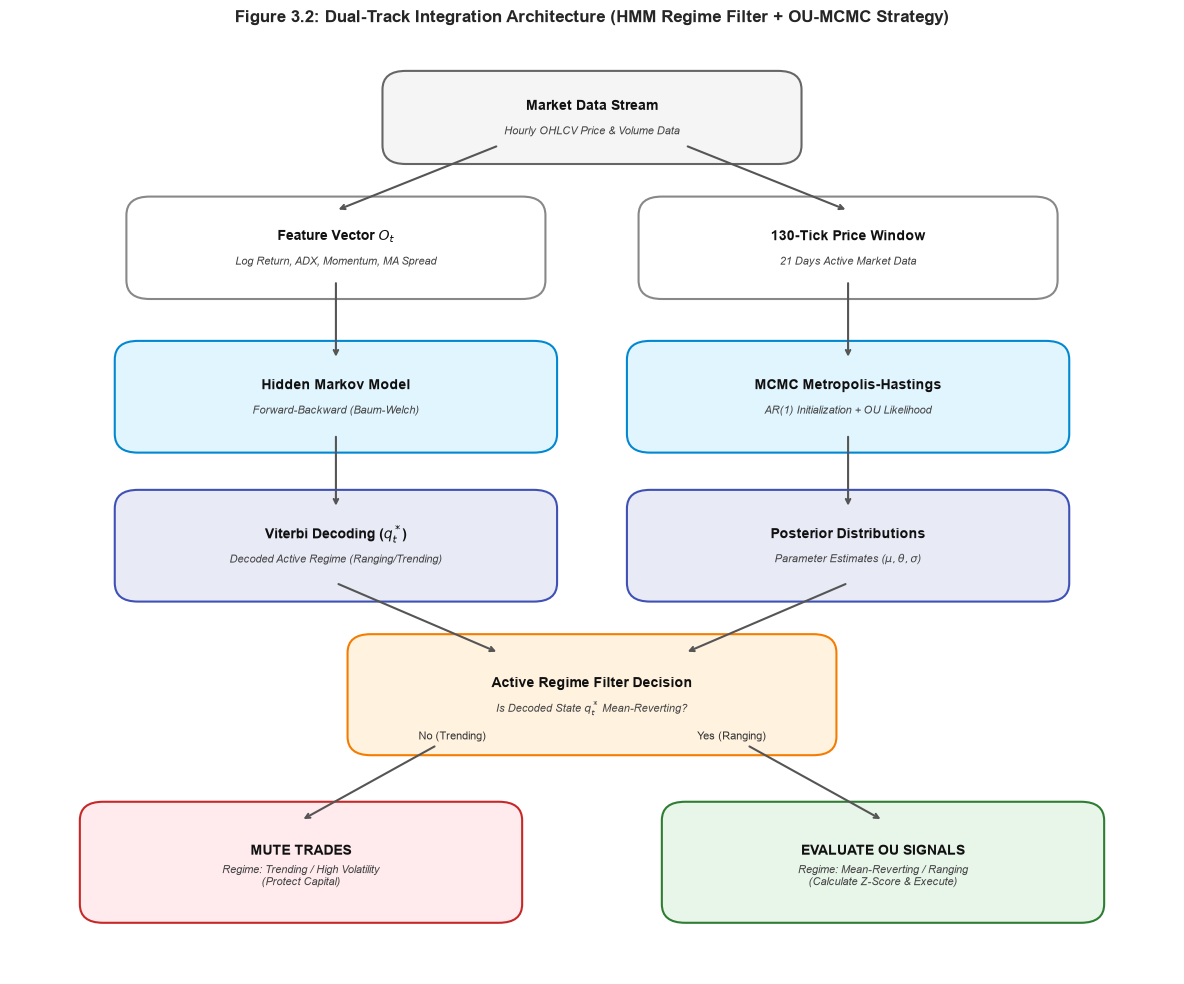

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Box drawing helper function
def add_box(ax, x, y, width, height, title, subtitle="", color='#e1f5fe', edgecolor='#0288d1'):
    rect = patches.FancyBboxPatch(
        (x - width/2, y - height/2), width, height,
        boxstyle="round,pad=0.2", facecolor=color, edgecolor=edgecolor, linewidth=1.5
    )
    ax.add_patch(rect)
    if subtitle:
        ax.text(x, y + 0.12, title, ha='center', va='center', fontsize=10, fontweight='bold', color='#111111')
        # FIX: Changed linestyle='italic' to fontstyle='italic'
        ax.text(x, y - 0.15, subtitle, ha='center', va='center', fontsize=8, fontstyle='italic', color='#444444')
    else:
        ax.text(x, y, title, ha='center', va='center', fontsize=10, fontweight='bold', color='#111111')

# Arrow drawing helper function
def add_arrow(ax, x1, y1, x2, y2, text=""):
    ax.annotate(
        text, xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(facecolor='#555555', edgecolor='#555555', arrowstyle="->", lw=1.5),
        ha='center', va='center', fontsize=8, color='#333333'
    )

# 1. INPUT LEVEL
add_box(ax, 5.0, 9.2, 3.2, 0.6, "Market Data Stream", "Hourly OHLCV Price & Volume Data", color='#f5f5f5', edgecolor='#666666')

# 2. FEATURE / DATA SPLIT LEVEL
add_box(ax, 2.8, 7.8, 3.2, 0.7, "Feature Vector $O_t$", "Log Return, ADX, Momentum, MA Spread", color='#ffffff', edgecolor='#888888')
add_box(ax, 7.2, 7.8, 3.2, 0.7, "130-Tick Price Window", "21 Days Active Market Data", color='#ffffff', edgecolor='#888888')

add_arrow(ax, 4.2, 8.9, 2.8, 8.2)
add_arrow(ax, 5.8, 8.9, 7.2, 8.2)

# 3. PARALLEL TRACK LEVEL
add_box(ax, 2.8, 6.2, 3.4, 0.8, "Hidden Markov Model", "Forward-Backward (Baum-Welch)", color='#e1f5fe', edgecolor='#0288d1')
add_box(ax, 7.2, 6.2, 3.4, 0.8, "MCMC Metropolis-Hastings", "AR(1) Initialization + OU Likelihood", color='#e1f5fe', edgecolor='#0288d1')

add_arrow(ax, 2.8, 7.45, 2.8, 6.6)
add_arrow(ax, 7.2, 7.45, 7.2, 6.6)

# 4. OUTPUT OF TRACKS
add_box(ax, 2.8, 4.6, 3.4, 0.8, "Viterbi Decoding ($q_t^*$)", "Decoded Active Regime (Ranging/Trending)", color='#e8eaf6', edgecolor='#3f51b5')
add_box(ax, 7.2, 4.6, 3.4, 0.8, "Posterior Distributions", "Parameter Estimates ($\mu, \\theta, \sigma$)", color='#e8eaf6', edgecolor='#3f51b5')

add_arrow(ax, 2.8, 5.8, 2.8, 5.0)
add_arrow(ax, 7.2, 5.8, 7.2, 5.0)

# 5. INTEGRATION & DECISION FILTER
add_box(ax, 5.0, 3.0, 3.8, 0.9, "Active Regime Filter Decision", "Is Decoded State $q_t^*$ Mean-Reverting?", color='#fff3e0', edgecolor='#f57c00')

add_arrow(ax, 2.8, 4.2, 4.2, 3.45)
add_arrow(ax, 7.2, 4.2, 5.8, 3.45)

# 6. DECISION BRANCH OUTCOMES
add_box(ax, 2.5, 1.2, 3.4, 0.9, "MUTE TRADES", "Regime: Trending / High Volatility\n(Protect Capital)", color='#ffebee', edgecolor='#c62828')
add_box(ax, 7.5, 1.2, 3.4, 0.9, "EVALUATE OU SIGNALS", "Regime: Mean-Reverting / Ranging\n(Calculate Z-Score & Execute)", color='#e8f5e9', edgecolor='#2e7d32')

add_arrow(ax, 3.8, 2.55, 2.5, 1.65, text="No (Trending)")
add_arrow(ax, 6.2, 2.55, 7.5, 1.65, text="Yes (Ranging)")

# Title
plt.title("Figure 3.2: Dual-Track Integration Architecture (HMM Regime Filter + OU-MCMC Strategy)", fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('system_architecture.png', dpi=300, bbox_inches='tight')
plt.show()

# Signal Generation and Trade Filtering

## The Z-Score and Mean Reversion
Signal generation in this framework relies on evaluating the magnitude of price deviation from its theoretical mean. The Z-score represents the number of standard deviations the current price ($x_t$) is away from the mean ($\mu$). By targeting extreme Z-scores (e.g., $z \geq 2$ or $z \leq -2$), we can identify instances of severe mispricing. At these extremes, there is a high statistical probability that the asset will revert to its mean.

## MCMC Posterior Distribution
To account for parameter uncertainty, the input data is passed through a Markov Chain Monte Carlo (MCMC) simulation. This generates a posterior distribution of Z-scores based on the sampled distributions of $\mu$, $\sigma$, and $\theta$. For each MCMC sample, the Z-score is computed as:

$$ z = \frac{\mu - x_t}{\sqrt{\frac{\sigma^2}{\theta^2}}} $$

This resulting distribution models the likelihood of observing specific Z-scores, with the median serving as the most robust point estimate. 

## Probability Mass and Trade Filtering
Rather than relying on a single point estimate, we analyze the Cumulative Distribution Function (CDF) of our MCMC output to quantify trade viability. We calculate the percentage of the probability mass that falls beyond our target thresholds (e.g., $2$ or $-2$). For example, if 80% of the distribution's mass exceeds the threshold, we can state with 80% confidence that an extreme mispricing event is occurring. 

However, exceeding the probability threshold (set dynamically to 75%) is only the first condition for signal generation. To ensure the reliability of the distribution and limit exposure to unquantifiable risks, the signal must pass a strict filtering process before a trade is accepted:

*   **Sign Conflict Check:** The system verifies that there is directional consensus across the model outputs, rejecting trades where underlying signals conflict.
*   **Fat-Tail Risk (Kurtosis):** To measure and cap our exposure to outlier risks, the distribution's kurtosis must remain below a predefined limit (`max_kurtosis = 3.0`). 
*   **Market Regime:** The strategy restricts trading during unfavorable macroeconomic or structural market regimes (specifically blocking trades during Regime 2).


# Buy Signal Execution and Position Sizing

Once a trade candidate passes the filtering stage, the system evaluates the mathematical expectancy of the trade and determines optimal capital allocation.

## Path Simulation and Reversion Probability
To model the actual mechanics of the trade, the system simulates 2,000 discrete price paths using a vectorized Euler-Maruyama discretization of the Ornstein-Uhlenbeck (O-U) process over a 130-period horizon. By sampling parameter sets ($\mu$, $\theta$, $\sigma$) directly from the MCMC posterior, the simulation inherently accounts for parameter uncertainty. The system calculates the empirical probability ($P_{revert}$) that the asset will successfully enter the 50% Highest Density Interval (HDI) of the mean within the 130-tick lifespan.






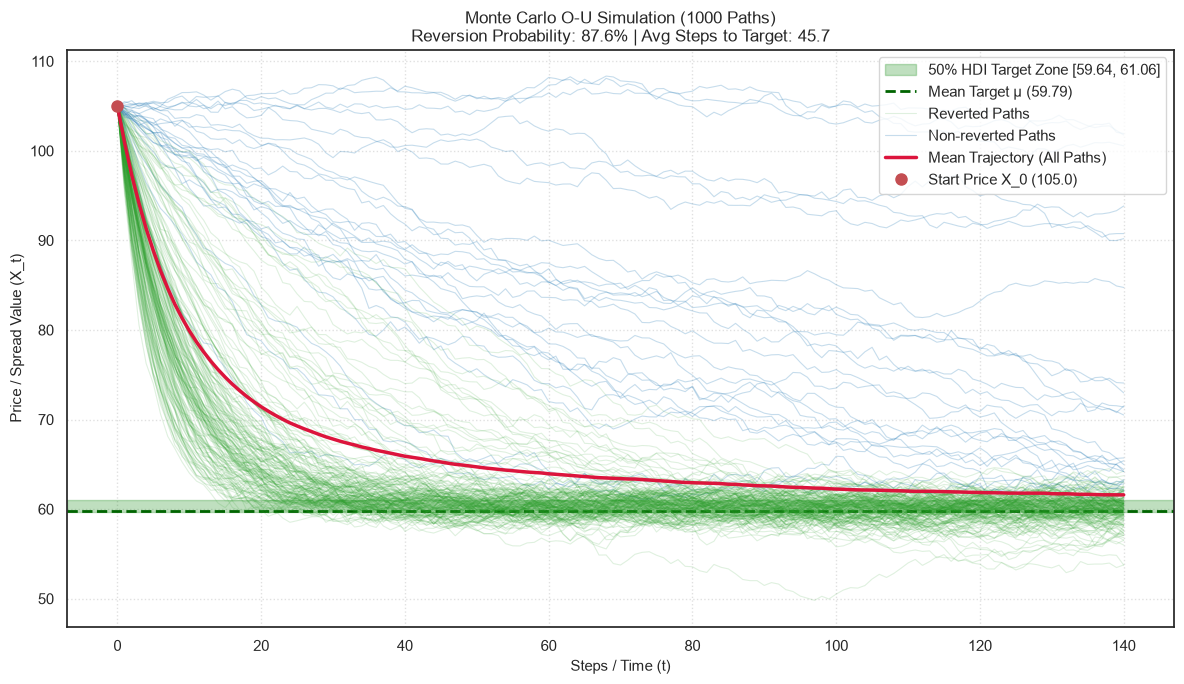

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load MCMC data
mcmc_filename = "mcmc_samples_backups/mcmc_20241216.npy"
prams_distrbatuion = np.load(mcmc_filename)


def calculate_target_zone_hdi(mu_samples, target_mass=0.50):
    total_samples = len(mu_samples)
    sorted_mu = np.sort(mu_samples)
    interval_count = int(np.floor(target_mass * total_samples))
    interval_widths = sorted_mu[interval_count:] - sorted_mu[:-interval_count]
    min_idx = np.argmin(interval_widths)
    return sorted_mu[min_idx], sorted_mu[min_idx + interval_count]


def plot_all_reversion_paths(
    mcmc_samples, xt, deltat=1, max_steps=140, num_paths=2000, display_paths=2000
):
    mcmc_samples = np.asarray(mcmc_samples)

    # 1. Sample parameters from posterior
    indices = np.random.choice(len(mcmc_samples), size=num_paths, replace=True)
    theta_samples = mcmc_samples[indices, 0]
    mu_samples = mcmc_samples[indices, 1]
    sigma_samples = mcmc_samples[indices, 2]

    # 2. Get target HDI bounds
    lower_hdi, upper_hdi = calculate_target_zone_hdi(
        mu_samples, target_mass=0.50
    )

    # 3. Simulate full matrix in advance: shape (max_steps + 1, num_paths)
    paths = np.zeros((max_steps + 1, num_paths))
    paths[0, :] = float(xt)

    hit_mask = np.zeros(num_paths, dtype=bool)
    first_hit_times = np.full(num_paths, max_steps + 1, dtype=float)

    for t in range(1, max_steps + 1):
        z = np.random.normal(0, 1, size=num_paths)
        prev = paths[t - 1, :]
        nxt = (
            prev
            + theta_samples * (mu_samples - prev) * deltat
            + sigma_samples * np.sqrt(deltat) * z
        )
        paths[t, :] = nxt

        in_zone = (nxt >= lower_hdi) & (nxt <= upper_hdi)
        new_hits = in_zone & (~hit_mask)
        first_hit_times[new_hits] = t
        hit_mask = hit_mask | in_zone

    # 4. Static Plotting
    plt.figure(figsize=(12, 7))
    time_steps = np.arange(max_steps + 1)

    # Shade the 50% HDI Target Zone
    plt.axhspan(
        lower_hdi,
        upper_hdi,
        color="green",
        alpha=0.25,
        label=f"50% HDI Target Zone [{lower_hdi:.2f}, {upper_hdi:.2f}]",
    )
    plt.axhline(
        np.mean(mu_samples),
        color="darkgreen",
        linestyle="--",
        linewidth=2,
        label=f"Mean Target μ ({np.mean(mu_samples):.2f})",
    )

    # Plot sample trajectories (green = reverted, blue = non-reverted)
    num_to_plot = min(num_paths, display_paths)
    reverted_plotted = False
    unreverted_plotted = False

    for i in range(num_to_plot):
        if hit_mask[i]:
            color = "tab:green"
            alpha = 0.15
            label = "Reverted Paths" if not reverted_plotted else ""
            reverted_plotted = True
        else:
            color = "tab:blue"
            alpha = 0.25
            label = "Non-reverted Paths" if not unreverted_plotted else ""
            unreverted_plotted = True

        plt.plot(
            time_steps,
            paths[:, i],
            color=color,
            alpha=alpha,
            linewidth=0.8,
            label=label,
        )

    # Mean trajectory across ALL simulated paths
    mean_trajectory = np.mean(paths, axis=1)
    plt.plot(
        time_steps,
        mean_trajectory,
        color="crimson",
        linewidth=2.5,
        label="Mean Trajectory (All Paths)",
    )

    # Mark starting point X_0
    plt.plot(
        0, xt, "ro", markersize=8, zorder=5, label=f"Start Price X_0 ({xt})"
    )

    prob_revert = (np.sum(hit_mask) / num_paths) * 100
    avg_steps = (
        np.mean(first_hit_times[hit_mask]) if np.any(hit_mask) else max_steps
    )

    plt.title(
        f"Monte Carlo O-U Simulation ({num_paths} Paths)\n"
        f"Reversion Probability: {prob_revert:.1f}% | Avg Steps to Target: {avg_steps:.1f}",
        fontsize=12,
    )
    plt.xlabel("Steps / Time (t)", fontsize=11)
    plt.ylabel("Price / Spread Value (X_t)", fontsize=11)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()


# Run static plot directly
plot_all_reversion_paths(
    prams_distrbatuion, xt=105.0, num_paths=1000, display_paths=200
)

## Expected Value (EV) Calculation
Using the simulated reversion probability, the framework strictly limits market entries to trades possessing a positive Expected Value (EV). The theoretical EV per share is calculated as:

$$ EV = (P_{revert} \times \text{Potential Gain}) - ((1 - P_{revert}) \times \text{Potential Loss}) $$

Where:
*   **Potential Gain** is the absolute distance between the current price and the target equilibrium price (the midpoint of the HDI zone).
*   **Potential Loss** is defined as an adverse price excursion equal to $3.5 \times \bar{\sigma}$, representing a structural failure of the model.

If the calculated EV is negative, or if the current price already resides inside the equilibrium zone, the system aborts the trade, returning a recommended size of zero.

## Confidence-Scaled Capital Allocation
For trades demonstrating a positive EV, capital is allocated using a dynamic risk budgeting approach. The system limits maximum exposure on any single trade to 2% of total portfolio capital. The base position size is calculated by dividing this risk budget by the potential loss per share. 

To optimize capital efficiency, this base size is then linearly scaled by the model's confidence ($P_{revert}$). Consequently, lower-probability setups consume a smaller fraction of the risk budget, while highly probable reversions utilize the maximum allowable allocation. Finally, the system verifies that the calculated notional value does not exceed available cash.

# Exit Mechanics and Stop-Loss Framework

The exit methodology within this framework relies on continuous evaluation of the posterior distributions to ensure positions are closed either when statistical mean reversion is achieved or when structural model assumptions are invalidated.

## Take-Profit: The 50% HDI Target Zone
Rather than utilizing a static price target, the take-profit mechanism is dynamically governed by the Highest Density Interval (HDI) of the expected mean ($\mu$). For each period, the model calculates the upper and lower bounds containing 50% of the $\mu$ posterior distribution's probability mass. 

When the current price ($x_t$) crosses into this 50% HDI box, it triggers a take-profit signal. This approach allows the system to execute the exit with a 50% statistical confidence that the asset has successfully reverted to its true population mean. 

## Distribution Health and Error Bounding
Before a take-profit or stop-loss order is executed based on distribution metrics, the model must validate the tightness and health of the underlying posterior. This acts as a secondary filter: the system calculates the 85% credible interval (spanning from the 7.5th to the 92.5th percentile) of the distribution. 

The exit logic is only authorized if the total width of this 85% mass is less than 3.0 units. By enforcing this strict threshold, the system guarantees that the posterior distribution is highly concentrated, mathematically capping the parameter estimation risk.

## Stop-Loss Logic
To protect the portfolio from structural breaks and regime shifts, the algorithm employs a dual-layered stop-loss framework:

*   **Time-Based Stop (130 Ticks):** A position is automatically liquidated if the holding period exceeds 130 observational ticks. This time-stop is critical for maintaining alignment with the original Expected Value (EV) and position sizing calculations, which were simulated over a maximum 140-step horizon. Limiting the time exposure ensures the initial MCMC parameters accurately reflect the current market environment and prevents macroeconomic regime drift.
*   **Structural Blowout (Z-Score $\geq 4$):** If the asset's standardized deviation (Z-score) expands beyond 4 (and the distribution width is stable), the position is immediately aborted. An extreme deviation of this magnitude falls well outside normal Gaussian expectations, signaling a fundamental structural break in the underlying asset's behavior. At this extreme, the asset has entered an exploratory market regime that the original O-U model parameters can no longer safely or accurately forecast.

## Backtest Performance & Results

Over the one-year backtest period, the mean-reverting algorithm successfully captured an **11.28% annual profit**. The system demonstrated highly efficient capital allocation, characterized by an exceptional profit factor and strictly managed downside risk. 

### Key Performance Metrics

**Return & Efficiency**
* **Win Rate:** 58.2% (across 18 total trades)
* **Profit Factor:** 4.50
* **Expectancy:** +0.97% per trade
* **Sharpe Ratio:** 1.17

**Risk Management**
* **Average Win:** +2.33%
* **Average Loss:** -0.71%
* **Max Drawdown:** -1.30%
* **Average Time in Market:** 10 Days, 18 Hours

### Trade Execution Analysis

As shown in the execution graph below, the algorithm consistently capitalized on localized downtrends by systematically selling high and buying low. Just as importantly, the risk-management logic successfully protected capital by preventing drawdowns when the Z-score flagged unpredictable volatility spikes.



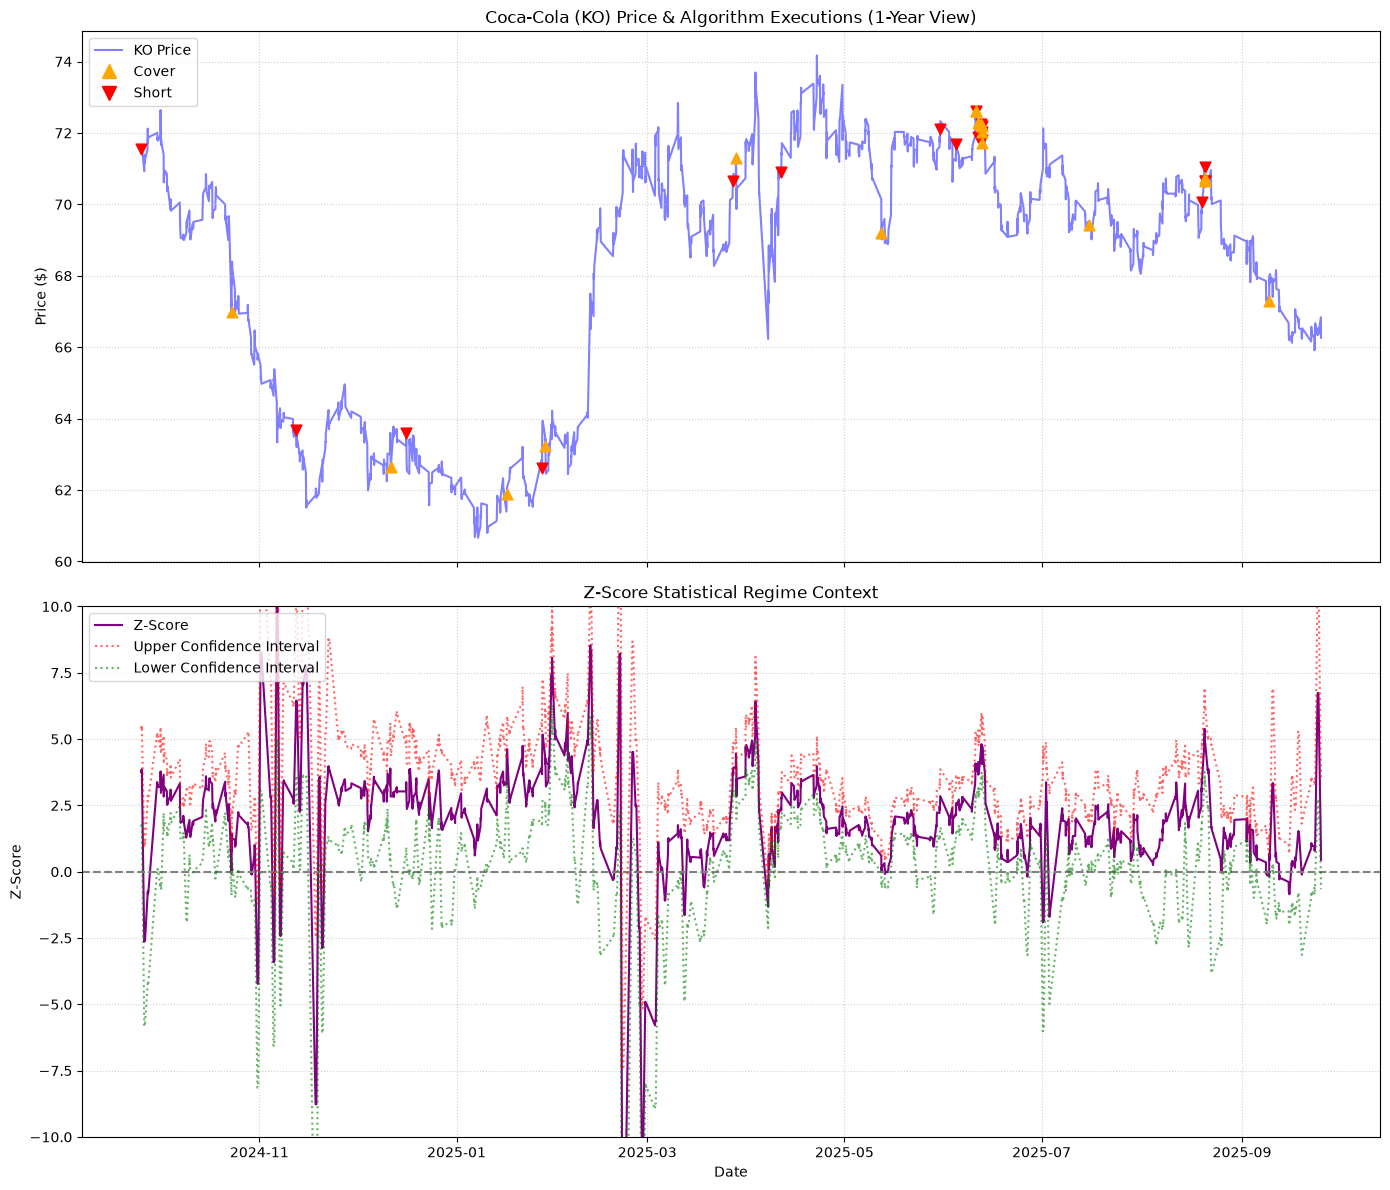

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 1. Load the data
master_log = pd.read_csv('trading_logs/master_daily_log_fast.csv')
trade_log = pd.read_csv('trading_logs/trade_log_fast.csv')

# Clean column names to prevent whitespace errors
master_log.columns = master_log.columns.str.strip()
trade_log.columns = trade_log.columns.str.strip()

# 2. Convert ALL dates to timezone-naive datetime objects first so they align perfectly
master_log['date'] = pd.to_datetime(master_log['date'], utc=True).dt.tz_localize(None)
trade_log['entry_time'] = pd.to_datetime(trade_log['entry_time'], utc=True).dt.tz_localize(None)
trade_log['exit_time'] = pd.to_datetime(trade_log['exit_time'], utc=True).dt.tz_localize(None)

# 3. Calculate the 1-year window based on the very first trade
first_date = trade_log['entry_time'].min()
one_year_later = first_date + pd.DateOffset(years=1)

# 4. FILTER BOTH dataframes to ONLY include this 1-year window
df = master_log[
    (master_log['date'] >= first_date) & 
    (master_log['date'] <= one_year_later)
].copy()

df_signals = trade_log[
    (trade_log['entry_time'] >= first_date) & 
    (trade_log['entry_time'] <= one_year_later)
].copy()

# 5. Separate the signals using your exact column 'trade_type'
long_trades = df_signals[df_signals['trade_type'] == 'LONG']
short_trades = df_signals[df_signals['trade_type'] == 'SHORT']

# 6. Setup the 2-pane figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Custom legend markers to reuse
buy_marker = mlines.Line2D([], [], color='orange', marker='^', linestyle='None', markersize=10, label='Cover')
sell_marker = mlines.Line2D([], [], color='red', marker='v', linestyle='None', markersize=10, label='Short')

# ---------------------------------------------------------
# PANE 1: KO Price & Executions
# ---------------------------------------------------------
ax1.plot(df['date'], df['current_price'], label='KO Price', color='blue', alpha=0.5, zorder=1)

# Long Executions
ax1.scatter(long_trades['entry_time'], long_trades['entry_price'], color='green', marker='^', s=60, zorder=3)
ax1.scatter(long_trades['exit_time'], long_trades['exit_price'], color='blue', marker='v', s=60, zorder=3)

# Short Executions
ax1.scatter(short_trades['entry_time'], short_trades['entry_price'], color='red', marker='v', s=60, zorder=3)
ax1.scatter(short_trades['exit_time'], short_trades['exit_price'], color='orange', marker='^', s=60, zorder=3)

handles, labels = ax1.get_legend_handles_labels()
handles.extend([buy_marker, sell_marker])
ax1.set_title("Coca-Cola (KO) Price & Algorithm Executions (1-Year View)")
ax1.legend(handles=handles, loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.set_ylabel('Price ($)')

# ---------------------------------------------------------
# PANE 2: Plot Z-Score with Confidence Intervals
# ---------------------------------------------------------
ax2.plot(df['date'], df['z_score'], label='Z-Score', color='purple')
ax2.axhline(0, color='gray', linestyle='--')
ax2.plot(df['date'], df['upper_ci'], color='red', linestyle=':', alpha=0.6, label='Upper Confidence Interval')
ax2.plot(df['date'], df['lower_ci'], color='green', linestyle=':', alpha=0.6, label='Lower Confidence Interval')

# Set y-limits on Z-Score to cut off extreme outliers and focus on the regime
ax2.set_ylim(-10, 10) 

ax2.set_title("Z-Score Statistical Regime Context")
ax2.legend(loc='upper left')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.set_ylabel('Z-Score')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

## Conclusion & Future Work

This paper demonstrates that while mean reversion is a mature strategy, applying rigorous stochastic modeling and probabilistic regime detection can yield a highly consistent trading algorithm. By anchoring the strategy in the continuous-time mathematics of the Ornstein-Uhlenbeck process and safeguarding it with strict, dynamic risk management protocols, the model successfully captures statistical market inefficiencies while structurally limiting catastrophic downside. Future

## Future Work

Moving forward, future iterations of this project will focus on several key enhancements to scale the algorithm and maximize alpha:

* **Long Position Optimization:** Refining the execution logic to better capture profit from long entries, ensuring the strategy is equally robust and profitable in both market directions.
* **Pairs Trading Integration:** Developing a more sophisticated pairs trading strategy designed to capitalize on two highly correlated assets, capturing profit as the spread between them mean-reverts.
* **Broad Market Scanning:** Expanding the universe of tradable assets by algorithmically searching for highly cointegrated stock pairs across the entire market to uncover new opportunities.
* **Advanced MCMC Tuning:** Implementing a better-tuned Markov Chain Monte Carlo (MCMC) model for rigorous parameter estimation (such as theta) to generate higher-fidelity trading signals.